# **Exploratory Data Analysis**

This notebook explores which weather and time variables are most associated with an I-80 closure beginning within the next 6, 12, or 24 hours. These are associations, not causal estimates.

## Setup and load the modeling data

In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / 'main' / 'data' / 'weather_closure_forecast_targets.csv').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the road_project root.')

FORECAST_PATH = PROJECT_ROOT / 'main' / 'data' / 'weather_closure_forecast_targets.csv'
OUTPUT_DIR = PROJECT_ROOT / 'main' / 'outputs' / 'eda'
SAVE_OUTPUTS = True
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120})

def finish_plot(filename):
    plt.tight_layout()
    if SAVE_OUTPUTS:
        plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

In [47]:
df = pd.read_csv(FORECAST_PATH, parse_dates=['date'])

required_columns = {
    'date', 'closure', 'closure_start',
    'will_close_in_6h', 'will_close_in_12h', 'will_close_in_24h'
}
assert required_columns.issubset(df.columns)
assert df['date'].notna().all() and df['date'].is_unique
assert df['date'].is_monotonic_increasing
assert df.isna().sum().sum() == 0

WINTER_MONTHS = {10, 11, 12, 1, 2, 3, 4, 5}
df['date_local'] = df['date'].dt.tz_convert('America/Los_Angeles')
assert set(df['date_local'].dt.month.unique()).issubset(WINTER_MONTHS)

TARGETS = ['will_close_in_6h', 'will_close_in_12h', 'will_close_in_24h']
WEATHER_FEATURES = [
    'temperature_2m', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_high',
    'cloud_cover_mid', 'wind_direction_100m', 'wind_direction_10m',
    'wind_speed_100m', 'wind_speed_10m', 'rain', 'snowfall', 'snow_depth',
    'weather_code', 'pressure_msl', 'surface_pressure', 'precipitation',
    'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m',
    'is_day', 'sunshine_duration'
]

print(f'Loaded: {FORECAST_PATH}')
print(f'Rows: {len(df):,}')
print(f'Closure starts: {df["closure_start"].sum():,}')
print(f'Date range: {df["date_local"].min()} through {df["date_local"].max()}')
df.head()

Loaded: /Users/hudson/Desktop/road_project/main/data/weather_closure_forecast_targets.csv
Rows: 49,429
Closure starts: 237
Date range: 2017-02-21 00:00:00-08:00 through 2026-03-04 23:00:00-08:00


,date,temperature_2m,cloud_cover,cloud_cover_low,cloud_cover_high,cloud_cover_mid,wind_direction_100m,wind_direction_10m,wind_speed_100m,wind_speed_10m,...,sunshine_duration,closure,year,month,winter,closure_start,will_close_in_6h,will_close_in_12h,will_close_in_24h,date_local
0,2017-02-21 08:00:00+00:00,33.08,99.0,97.0,35.0,77.0,217.44579,218.21107,44.518547,26.761850,...,0.0,0.0,2017,2,2016-2017,0,0,0,1,2017-02-21 00:00:00-08:00
1,2017-02-21 09:00:00+00:00,30.56,100.0,93.0,95.0,53.0,232.39394,232.49579,41.790607,24.250565,...,0.0,0.0,2017,2,2016-2017,0,0,0,1,2017-02-21 01:00:00-08:00
2,2017-02-21 10:00:00+00:00,30.20,97.0,80.0,83.0,78.0,216.61449,216.14214,40.132180,24.653728,...,0.0,0.0,2017,2,2016-2017,0,0,0,1,2017-02-21 02:00:00-08:00
3,2017-02-21 11:00:00+00:00,30.20,100.0,100.0,86.0,99.0,216.73291,216.86998,37.402744,22.369999,...,0.0,0.0,2017,2,2016-2017,0,0,0,1,2017-02-21 03:00:00-08:00
4,2017-02-21 12:00:00+00:00,29.03,100.0,99.0,93.0,92.0,223.61638,223.05852,32.752770,18.675936,...,0.0,0.0,2017,2,2016-2017,0,0,0,1,2017-02-21 04:00:00-08:00


## Target balance

Accuracy is not a useful primary metric for rare closures, so this section makes the imbalance visible before modeling.

,positive_rows,positive_rate,negative_rows
target,,,
will_close_in_6h,971,0.0196,48458
will_close_in_12h,1876,0.0380,47553
will_close_in_24h,3531,0.0714,45898


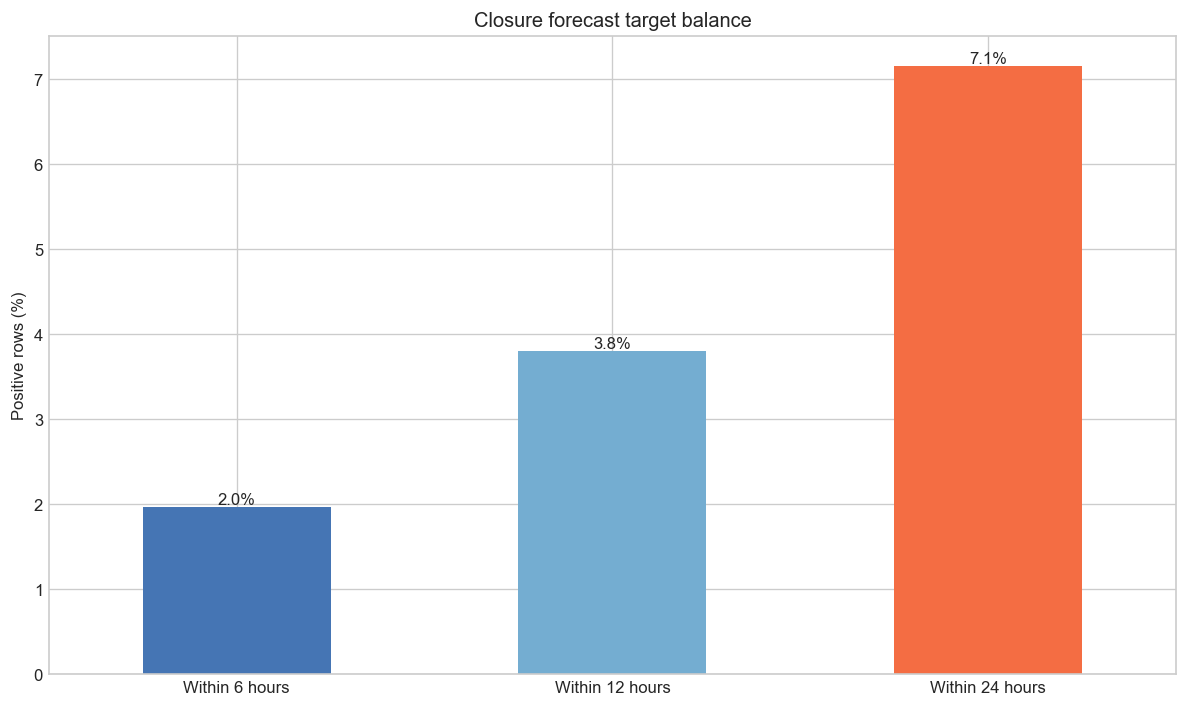

In [48]:
target_summary = pd.DataFrame({
    'positive_rows': df[TARGETS].sum(),
    'positive_rate': df[TARGETS].mean(),
    'negative_rows': (df[TARGETS] == 0).sum(),
})
target_summary.index.name = 'target'
display(target_summary.assign(positive_rate=target_summary['positive_rate'].round(4)))
if SAVE_OUTPUTS:
    target_summary.to_csv(OUTPUT_DIR / 'target_balance.csv')

ax = (target_summary['positive_rate'] * 100).plot.bar(color=['#4575b4', '#74add1', '#f46d43'])
ax.set(title='Closure forecast target balance', ylabel='Positive rows (%)', xlabel='')
ax.set_xticklabels(['Within 6 hours', 'Within 12 hours', 'Within 24 hours'], rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
finish_plot('01_target_balance.png')

## Weather correlations with future closures

For a binary target, Pearson correlation is the point-biserial correlation. Rare outcomes naturally produce modest coefficients, so correlations are considered alongside standardized mean differences below. Wind direction is excluded from this ranking because degrees are circular.

,will_close_in_6h,will_close_in_12h,will_close_in_24h,max_abs_correlation
snowfall,0.160,0.168,0.175,0.175
precipitation,0.154,0.164,0.174,0.174
weather_code,0.131,0.152,0.172,0.172
surface_pressure,-0.108,-0.149,-0.169,0.169
cloud_cover_mid,0.113,0.138,0.155,0.155
wind_speed_100m,0.086,0.120,0.153,0.153
wind_speed_10m,0.088,0.116,0.146,0.146
cloud_cover_low,0.101,0.125,0.144,0.144
pressure_msl,-0.079,-0.099,-0.127,0.127
cloud_cover,0.073,0.094,0.121,0.121


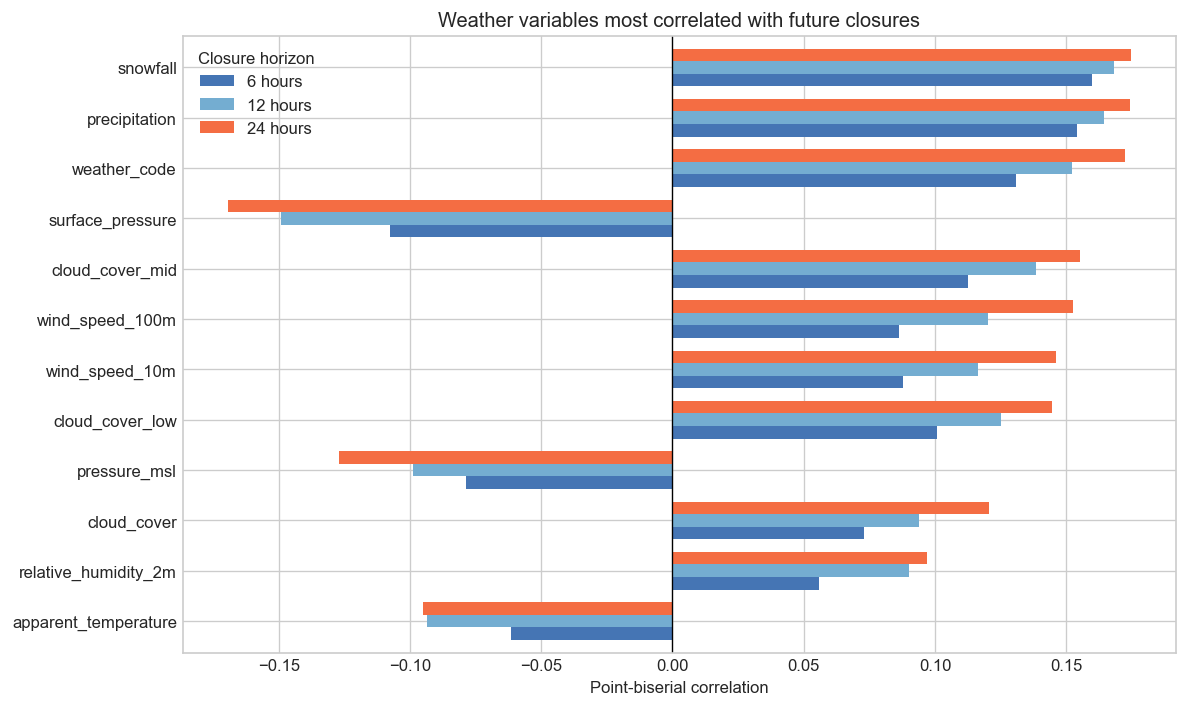

In [49]:
CORRELATION_FEATURES = [c for c in WEATHER_FEATURES if not c.startswith('wind_direction')]
correlation_table = pd.DataFrame({
    target: df[CORRELATION_FEATURES + [target]].corr()[target].drop(target)
    for target in TARGETS
})
correlation_table['max_abs_correlation'] = correlation_table.abs().max(axis=1)
correlation_table = correlation_table.sort_values('max_abs_correlation', ascending=False)
display(correlation_table.round(3))
if SAVE_OUTPUTS:
    correlation_table.to_csv(OUTPUT_DIR / 'weather_target_correlations.csv')

top_features = correlation_table.head(12).index[::-1]
plot_data = correlation_table.loc[top_features, TARGETS]
ax = plot_data.plot.barh(width=0.75, color=['#4575b4', '#74add1', '#f46d43'])
legend_handles, _ = ax.get_legend_handles_labels()
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Weather variables most correlated with future closures', xlabel='Point-biserial correlation', ylabel='')
ax.legend(legend_handles, ['6 hours', '12 hours', '24 hours'], title='Closure horizon')
finish_plot('02_weather_target_correlations.png')

## Effect sizes at closure starts

A standardized mean difference compares weather during closure-start hours with all other winter hours. Its magnitude is easier to compare across variables measured in different units.

,closure_start_mean,other_hour_mean,standardized_difference,absolute_difference
feature,,,,
weather_code,48.215,13.206,1.144,1.144
cloud_cover_low,68.367,27.372,1.006,1.006
cloud_cover_mid,62.447,23.477,0.969,0.969
surface_pressure,777.069,782.777,-0.918,0.918
snowfall,0.348,0.040,0.891,0.891
precipitation,0.051,0.007,0.875,0.875
cloud_cover,80.772,51.902,0.737,0.737
pressure_msl,1014.651,1019.309,-0.718,0.718
apparent_temperature,20.427,27.038,-0.567,0.567


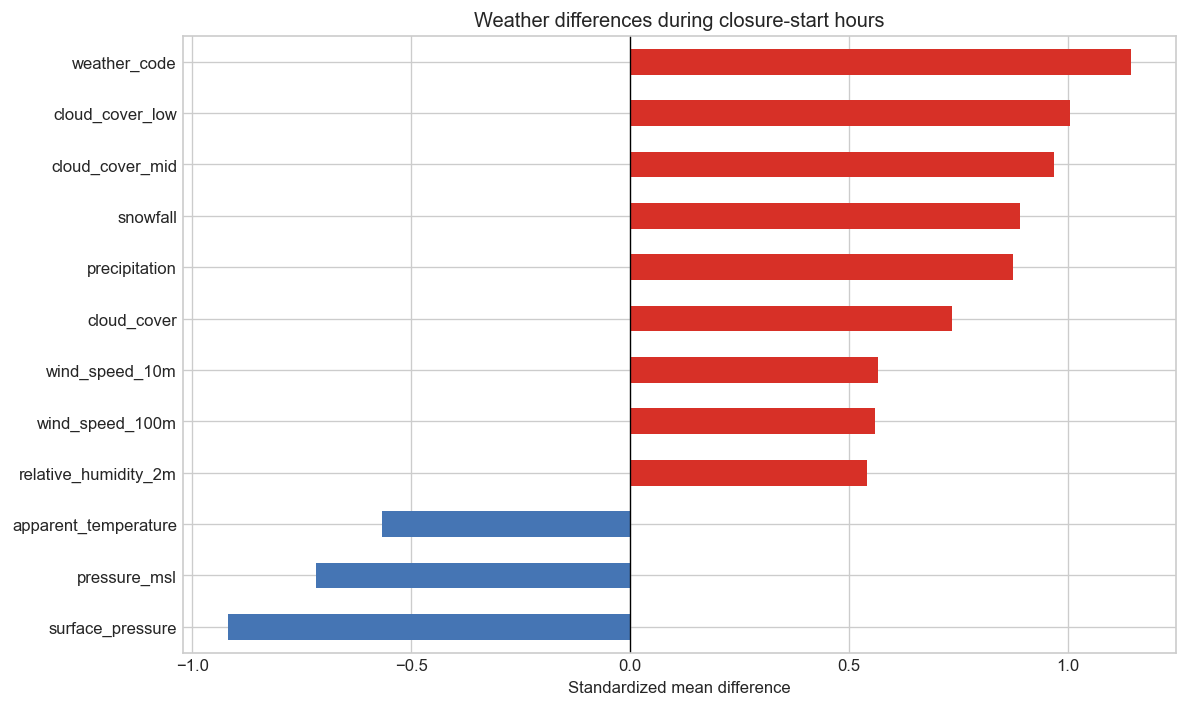

In [50]:
effect_rows = []
for feature in CORRELATION_FEATURES:
    closure_values = df.loc[df['closure_start'].eq(1), feature]
    other_values = df.loc[df['closure_start'].eq(0), feature]
    pooled_sd = np.sqrt((closure_values.var() + other_values.var()) / 2)
    effect_rows.append({
        'feature': feature,
        'closure_start_mean': closure_values.mean(),
        'other_hour_mean': other_values.mean(),
        'standardized_difference': (closure_values.mean() - other_values.mean()) / pooled_sd,
    })
effect_table = pd.DataFrame(effect_rows).set_index('feature')
effect_table['absolute_difference'] = effect_table['standardized_difference'].abs()
effect_table = effect_table.sort_values('absolute_difference', ascending=False)
display(effect_table.round(3))
if SAVE_OUTPUTS:
    effect_table.to_csv(OUTPUT_DIR / 'closure_start_effect_sizes.csv')

plot_effect = effect_table.head(12).sort_values('standardized_difference')
colors = np.where(plot_effect['standardized_difference'] >= 0, '#d73027', '#4575b4')
ax = plot_effect['standardized_difference'].plot.barh(color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Weather differences during closure-start hours', xlabel='Standardized mean difference', ylabel='')
finish_plot('03_closure_start_effect_sizes.png')

## Distributions of important weather variables

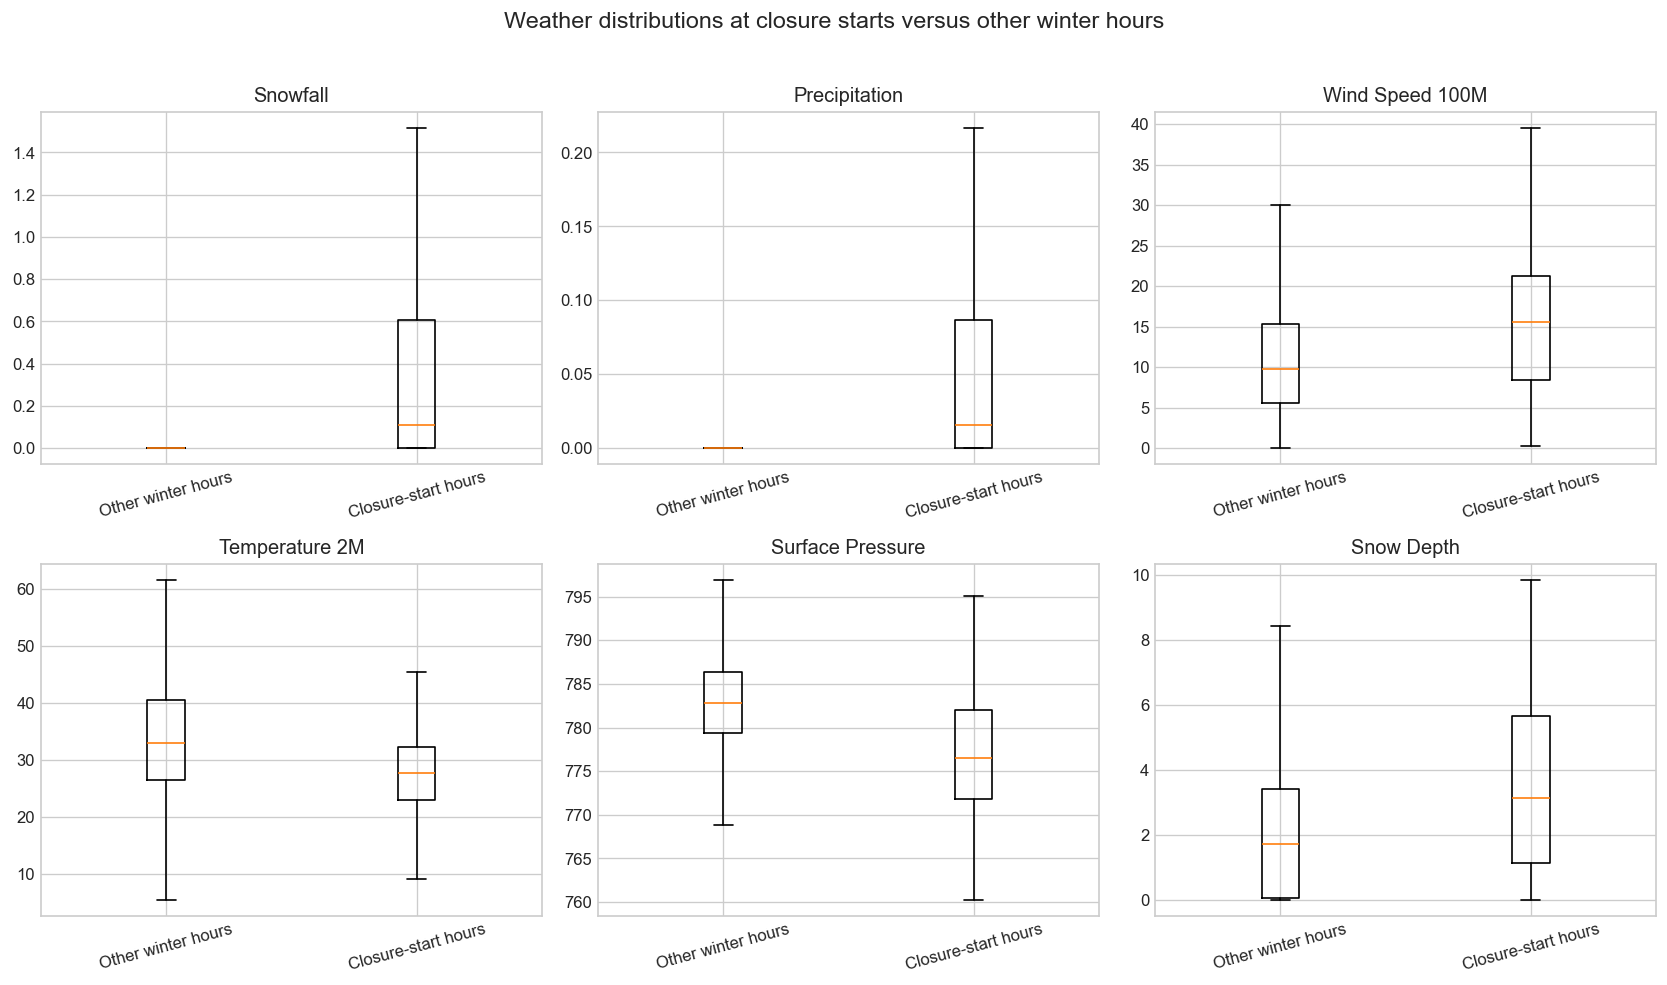

In [51]:
distribution_features = ['snowfall', 'precipitation', 'wind_speed_100m', 'temperature_2m', 'surface_pressure', 'snow_depth']
labels = ['Other winter hours', 'Closure-start hours']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feature in zip(axes.flat, distribution_features):
    values = [
        df.loc[df['closure_start'].eq(0), feature],
        df.loc[df['closure_start'].eq(1), feature],
    ]
    ax.boxplot(values, tick_labels=labels, showfliers=False)
    ax.set_title(feature.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=15)
fig.suptitle('Weather distributions at closure starts versus other winter hours', y=1.02, fontsize=14)
finish_plot('04_weather_distributions.png')

## Closure timing

Rates use the number of observed hours as the denominator, avoiding misleading comparisons between partial and complete months.

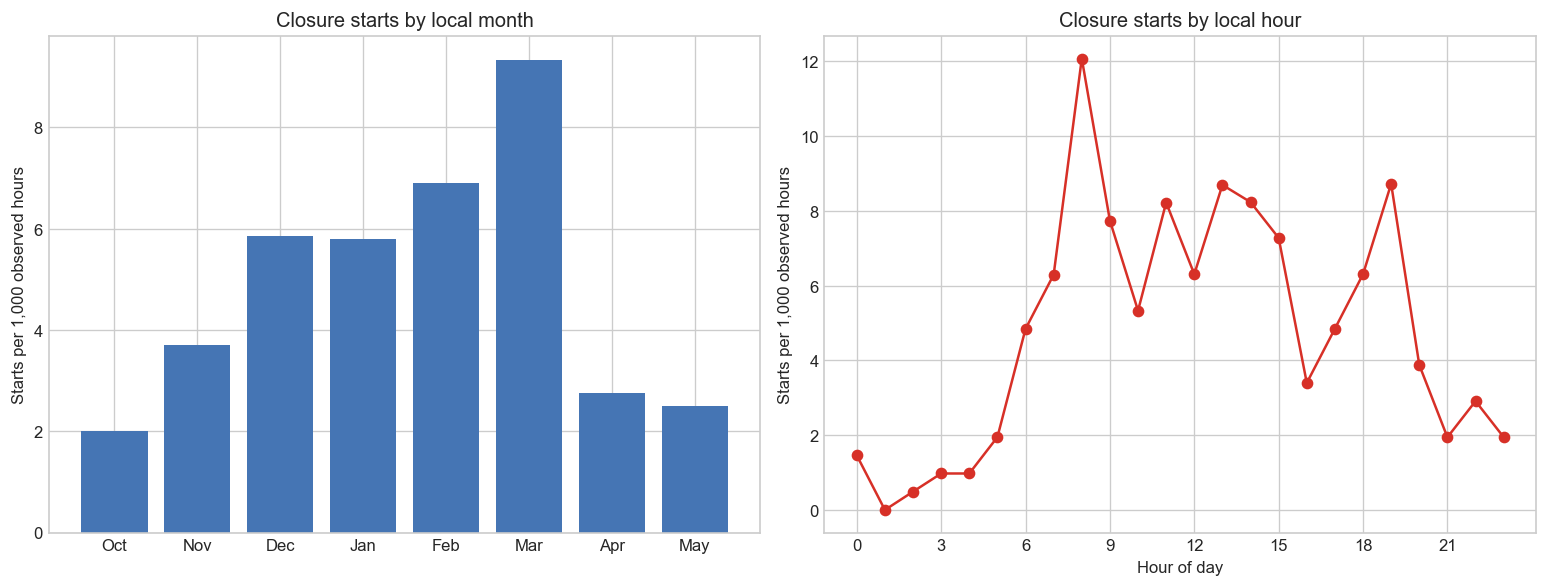

In [52]:
df['local_month'] = df['date_local'].dt.month
df['local_hour'] = df['date_local'].dt.hour
month_order = [10, 11, 12, 1, 2, 3, 4, 5]
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
monthly_rate = df.groupby('local_month')['closure_start'].mean().reindex(month_order) * 1000
hourly_rate = df.groupby('local_hour')['closure_start'].mean() * 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(month_names, monthly_rate, color='#4575b4')
axes[0].set(title='Closure starts by local month', ylabel='Starts per 1,000 observed hours')
axes[1].plot(hourly_rate.index, hourly_rate.values, marker='o', color='#d73027')
axes[1].set(title='Closure starts by local hour', xlabel='Hour of day', ylabel='Starts per 1,000 observed hours', xticks=range(0, 24, 3))
finish_plot('05_closure_timing.png')

timing_table = pd.DataFrame({'month': month_order, 'month_name': month_names, 'starts_per_1000_hours': monthly_rate.values})
if SAVE_OUTPUTS:
    timing_table.to_csv(OUTPUT_DIR / 'monthly_closure_rates.csv', index=False)

## Weather leading up to closure starts

This event-study view averages weather at each hour before a closure begins. It shows the typical trajectory without selecting one unusually severe storm.

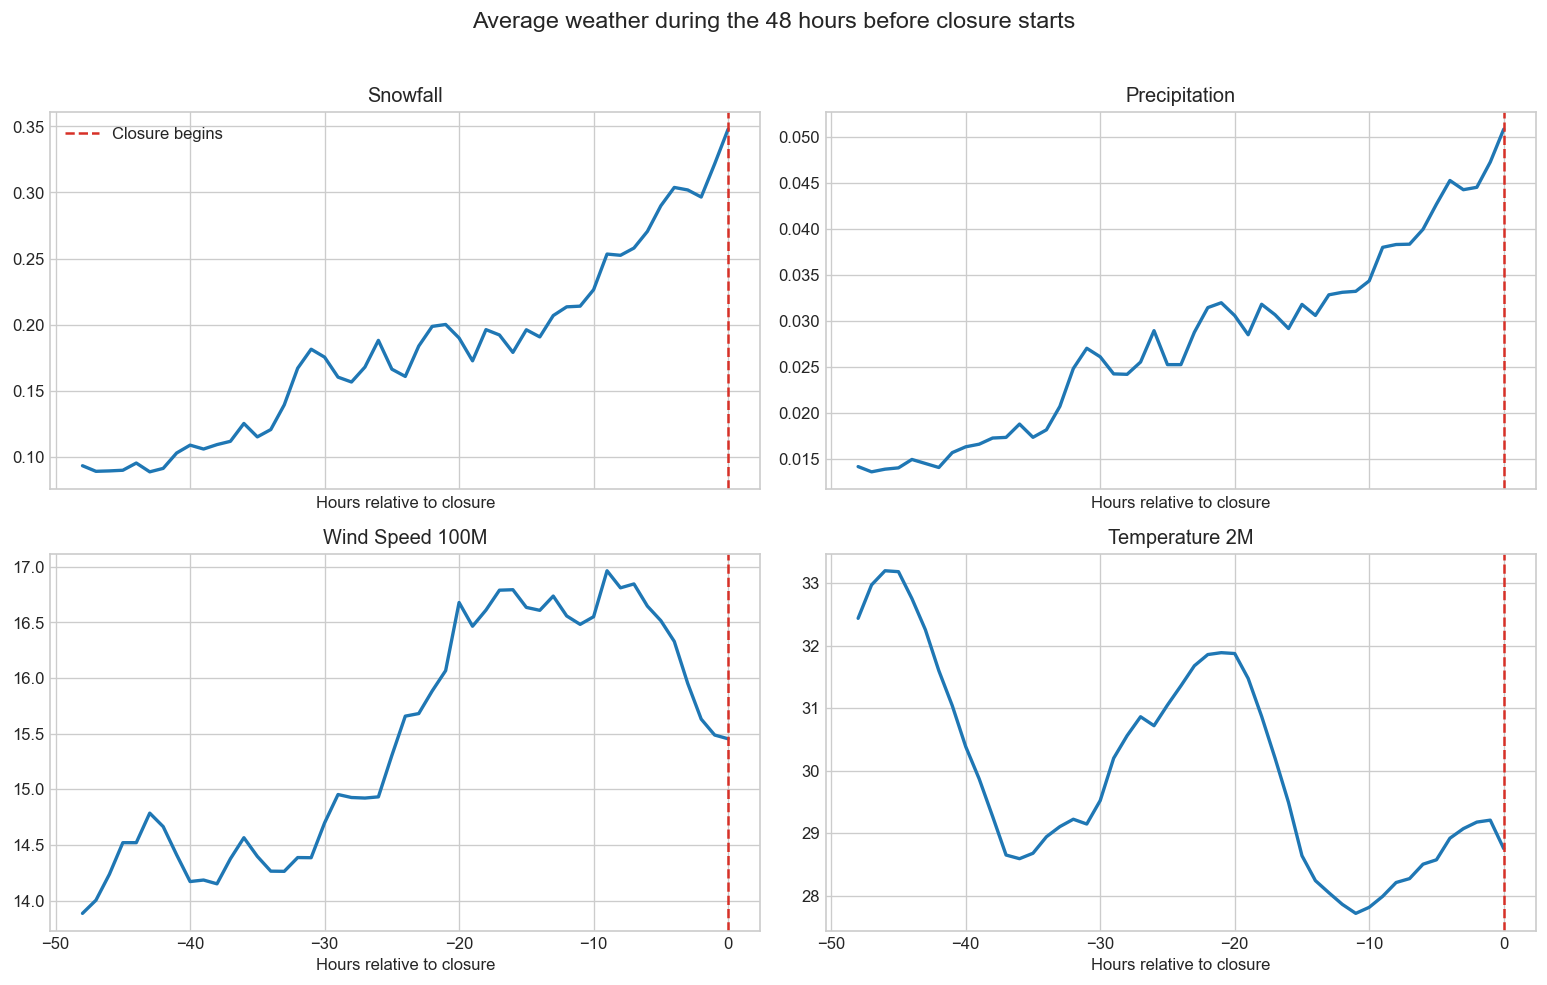

In [53]:
trajectory_features = ['snowfall', 'precipitation', 'wind_speed_100m', 'temperature_2m']
weather_by_time = df.set_index('date')[trajectory_features]
closure_times = df.loc[df['closure_start'].eq(1), 'date'].drop_duplicates()
trajectory_rows = []
for event_number, closure_time in enumerate(closure_times):
    for hours_before in range(48, -1, -1):
        timestamp = closure_time - pd.Timedelta(hours=hours_before)
        if timestamp in weather_by_time.index:
            row = weather_by_time.loc[timestamp].to_dict()
            row.update({'event_number': event_number, 'hours_to_closure': -hours_before})
            trajectory_rows.append(row)
trajectory = pd.DataFrame(trajectory_rows)
trajectory_summary = trajectory.groupby('hours_to_closure')[trajectory_features].agg(['mean', 'count'])
if SAVE_OUTPUTS:
    trajectory_summary.to_csv(OUTPUT_DIR / 'preclosure_weather_trajectory.csv')

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, feature in zip(axes.flat, trajectory_features):
    means = trajectory_summary[(feature, 'mean')]
    ax.plot(means.index, means.values, linewidth=2)
    ax.axvline(0, color='#d73027', linestyle='--', label='Closure begins')
    ax.set(title=feature.replace('_', ' ').title(), xlabel='Hours relative to closure')
axes[0, 0].legend()
fig.suptitle('Average weather during the 48 hours before closure starts', y=1.02, fontsize=14)
finish_plot('06_preclosure_weather_trajectory.png')

## Predictor redundancy

Highly correlated predictors may describe the same weather process. This matters most when interpreting linear-model coefficients.

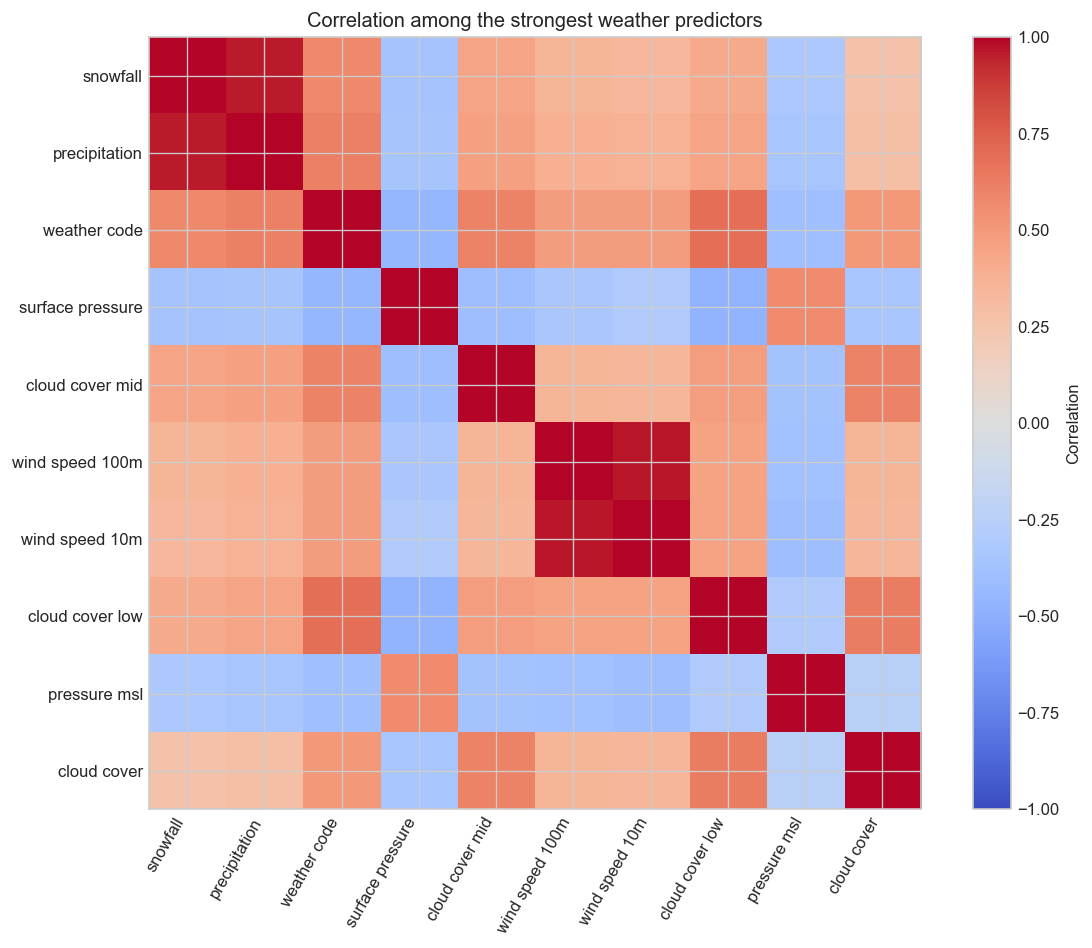

In [54]:
top_predictors = correlation_table.head(10).index.tolist()
predictor_correlation = df[top_predictors].corr()
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(predictor_correlation, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(top_predictors)), [x.replace('_', ' ') for x in top_predictors], rotation=60, ha='right')
ax.set_yticks(range(len(top_predictors)), [x.replace('_', ' ') for x in top_predictors])
fig.colorbar(image, ax=ax, label='Correlation')
ax.set_title('Correlation among the strongest weather predictors')
finish_plot('07_predictor_correlation_heatmap.png')

## EDA conclusions

The strongest weather correlations are consistent across all three horizons. For the 24-hour target, snowfall (`r = 0.175`), precipitation (`r = 0.174`), weather severity code (`r = 0.172`), lower surface pressure (`r = -0.169`), mid-level cloud cover (`r = 0.155`), and 100 m wind speed (`r = 0.153`) lead the ranking.

Closure-start hours also show practically large differences from other winter hours: weather severity (`SMD = 1.14`), low cloud cover (`1.01`), mid-level cloud cover (`0.97`), lower surface pressure (`-0.92`), snowfall (`0.89`), and precipitation (`0.88`). The pre-closure event study shows snowfall and precipitation rising as closure time approaches. March has the highest observed rate at about 9.34 starts per 1,000 monitored hours.

These results support using snow, precipitation, pressure, cloud, wind, temperature, snow depth, and cyclical time features in the first predictive models. They remain associations and may partly represent the same storm process. Use the ranked tables above as the evidence for feature selection, not a single chart. Before modeling:

- keep train/validation/test splits chronological by winter;
- never use `closure`, `closure_start`, or another horizon target as a predictor;
- build rolling features using past weather only;
- encode month, hour, and wind direction cyclically;
- judge performance with precision-recall metrics and false alerts per day.